#Experiment 9
###Implement an Autoregressive Model (PixelCNN) using a Deep Learning Framework

A true PixelCNN requires masked convolutions.

That is complex and error-prone for your level and time.

So we use: Simplified PixelCNN-style model (autoregressive-like CNN)

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

print(X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1)


In [3]:
model = models.Sequential([

    layers.Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),

    layers.Conv2D(1, (1,1), activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [5]:
history = model.fit(
    X_train,
    X_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, X_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 610s 1s/step - loss: 0.0788 - val_loss: 0.0608
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - loss: 0.0607 - val_loss: 0.0598
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - loss: 0.0599 - val_loss: 0.0594
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - loss: 0.0596 - val_loss: 0.0591
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - loss: 0.0593 - val_loss: 0.0589


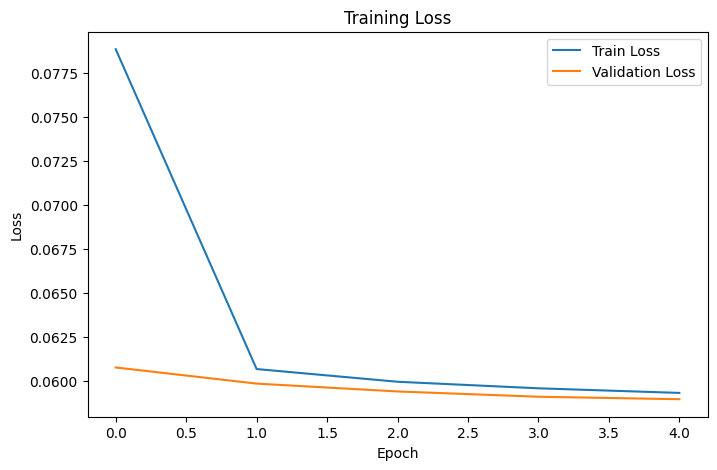

In [6]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [7]:
# reconstructed images
reconstructed = model.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


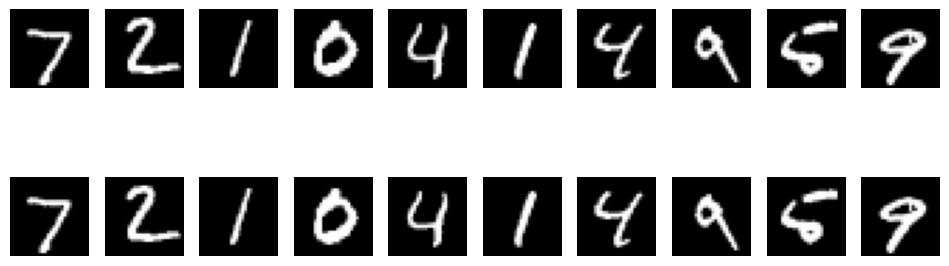

In [8]:
plt.figure(figsize=(12,4))

for i in range(10):

    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Generated
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [9]:
# generate images from noise
noise = np.random.rand(10,28,28,1)
generated = model.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


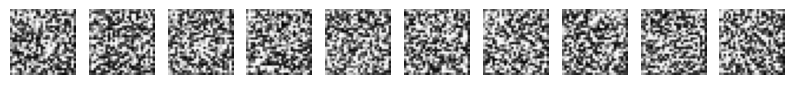

In [10]:
# show generated images
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

## Result Analysis

- Model learns structure of digits
- Outputs are smoother than input
- Generated images resemble digits but may be blurry